# Unemployment Analysis with Python

## Project Overview

This project analyzes unemployment data in India to identify regional and
temporal trends in unemployment rates, with a focus on the impact of the
COVID-19 pandemic.

## Objectives

- Explore and understand the unemployment dataset
- Analyze unemployment rates across different regions
- Study monthly and time-based unemployment trends
- Compare unemployment before and after COVID-19
- Visualize important patterns using charts
- Identify regions with higher average unemployment rates

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset

The dataset contains unemployment-related information for different regions
of India, including unemployment rate, employment rate, and labour
participation rate.

## 1. Import Required Libraries

The following Python libraries are used in this project:

- **Pandas:** Used for loading, cleaning, and analyzing the unemployment dataset.
- **NumPy:** Used for numerical operations and calculations.
- **Matplotlib:** Used for creating data visualizations and charts.
- **Seaborn:** Used for statistical visualizations such as heatmaps and plots.

These libraries provide the basic tools required for exploratory data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The unemployment dataset is stored in a CSV (Comma-Separated Values) file.

We use the Pandas `read_csv()` function to load the dataset into a DataFrame.

A DataFrame is a table-like structure in Pandas that allows us to easily
inspect, clean, analyze, and visualize the data.

In [2]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Dataset Shape

The `shape` attribute is used to find the number of rows and columns in the dataset.

It returns a tuple in the format:

`(number of rows, number of columns)`

This helps us understand the size of the dataset before performing further analysis.

In [3]:
df.shape

(267, 9)

### Dataset Size

The dataset contains **267 rows and 9 columns**.

- **Rows:** 267
- **Columns:** 9

This gives us an initial understanding of the size of the dataset before performing data cleaning and exploratory analysis.

## 4. Dataset Information

The `info()` method provides important information about the dataset, including:

- Column names
- Number of non-null values
- Data types
- Memory usage

This helps us identify columns that may require data cleaning or type conversion.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


## 5. Checking for Missing Values

Missing values can affect data analysis and machine learning models.

We use the `isnull()` method to identify missing values in each column.

The `sum()` method counts the total number of missing values for every column.

This step helps us determine whether the dataset requires missing-value treatment before analysis.

In [5]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

### Missing Value Observation

The missing-value check shows that all columns contain **0 missing values**.

Therefore, no missing-value treatment is required for this dataset at this stage.
The dataset is complete with respect to missing values.

## 6. Cleaning Column Names

While inspecting the dataset, we noticed that some column names contain
unnecessary leading or trailing spaces.

Extra spaces in column names can cause errors when accessing columns.

We will remove these unwanted spaces using the `str.strip()` method so that
the column names are clean and easier to work with.

In [6]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

## 7. Convert Date Column

The `Date` column was initially stored as an object (text) data type.

For time-series analysis, we need the dates in a proper datetime format.
Therefore, we convert the `Date` column using Pandas `to_datetime()` function.

This will allow us to analyze unemployment trends by month and compare
different time periods.

In [7]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    object        
 1   Date                                     267 non-null    datetime64[ns]
 2   Frequency                                267 non-null    object        
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4   Estimated Employed                       267 non-null    int64         
 5   Estimated Labour Participation Rate (%)  267 non-null    float64       
 6   Region.1                                 267 non-null    object        
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

### Date Conversion Observation

The `Date` column was successfully converted from an object data type to
`datetime64[ns]`.

The dataset uses a day-month-year date format, so `dayfirst=True` was used
during conversion.

This conversion is important because it allows us to perform time-series
analysis and compare unemployment trends across different periods.

## 8. Descriptive Statistics

Descriptive statistics provide a summary of the numerical columns in the
dataset.

The `describe()` function calculates important statistical measures such as:

- Count
- Mean
- Standard deviation
- Minimum value
- 25th percentile
- Median (50th percentile)
- 75th percentile
- Maximum value

These statistics help us understand the distribution and range of
unemployment, employment, and labour participation values.

In [8]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


### Descriptive Statistics Observation

The dataset contains 267 observations covering the period from January 2020
to October 2020.

The average unemployment rate is approximately **12.24%**, while the minimum
and maximum unemployment rates are **0.50%** and **75.85%**, respectively.
This indicates considerable variation in unemployment across different
regions and time periods.

The average labour participation rate is approximately **41.68%**, and the
average estimated employed population is around **13.96 million**.

The large difference between the minimum and maximum unemployment rates
suggests that unemployment conditions varied significantly across regions
during the study period.

## 9. Understanding the Regions

The dataset contains unemployment information for multiple states and
regions of India.

We will examine the unique region names and count how many different
regions are represented in the dataset.

This will help us perform region-wise unemployment analysis later.

In [9]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal'], dtype=object)

### Region Observation

The dataset contains unemployment information for **27 different regions/states**
of India.

The regions include states and union territories such as Andhra Pradesh,
Karnataka, Maharashtra, Delhi, Kerala, Tamil Nadu, and West Bengal.

This regional information will allow us to compare unemployment rates across
different parts of India.

In [10]:
df['Region'].nunique()

27

In [11]:
df['Region'].value_counts()

Region
Andhra Pradesh      10
Assam               10
Bihar               10
Chhattisgarh        10
Delhi               10
Goa                 10
Gujarat             10
Haryana             10
Himachal Pradesh    10
Jharkhand           10
Karnataka           10
Rajasthan           10
Kerala              10
Madhya Pradesh      10
Maharashtra         10
Meghalaya           10
Odisha              10
Puducherry          10
Punjab              10
Uttarakhand         10
Tamil Nadu          10
Telangana           10
Tripura             10
West Bengal         10
Uttar Pradesh       10
Jammu & Kashmir      9
Sikkim               8
Name: count, dtype: int64

### Region Distribution Observation

The dataset contains multiple observations for each region.

Most regions have **10 records**, while Jammu & Kashmir has **9 records**
and Sikkim has **8 records**.

Therefore, the number of observations is slightly different for a few
regions. This difference should be considered when comparing regional
statistics.

## 10. Region-wise Average Unemployment Rate

To compare unemployment conditions across different regions, we calculate
the average unemployment rate for each region.

We use the Pandas `groupby()` function to group the data by region and then
calculate the mean unemployment rate for each group.

This analysis helps us identify regions with relatively higher or lower
average unemployment rates during the study period.

In [12]:
region_avg_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

region_avg_unemployment

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

### Observation

Haryana has the highest average unemployment rate at about 27.48%.
Tripura, Jharkhand, and Bihar also have high average unemployment rates.

Meghalaya has the lowest average unemployment rate at about 3.87%.
This shows that unemployment rates are different across the regions.

## 11. Top 10 Regions with Highest Average Unemployment

Here we select the top 10 regions with the highest average unemployment
rates.

A bar chart makes it easier to compare the unemployment rates between
these regions.

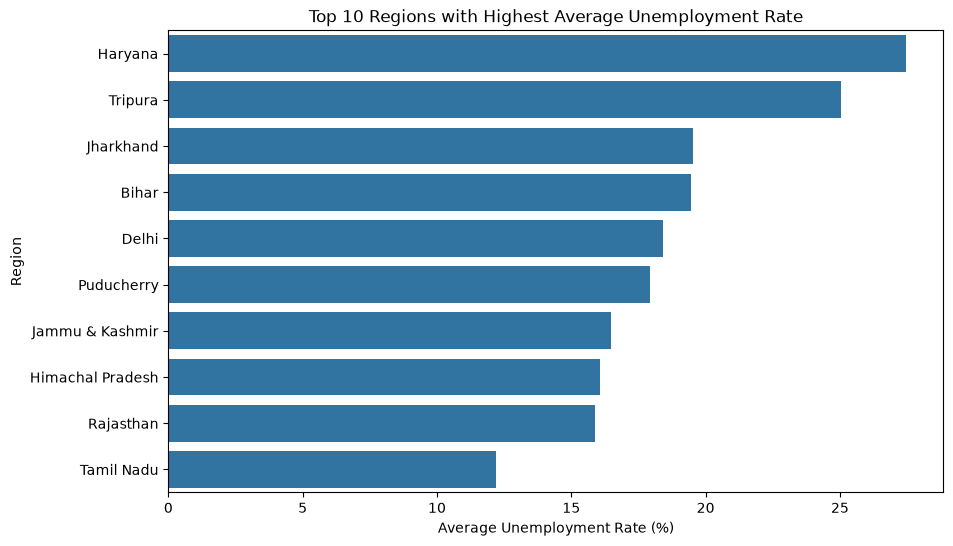

In [13]:
top_10_regions = region_avg_unemployment.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()

### Observation

Haryana has the highest average unemployment rate among the top 10 regions,
followed by Tripura.

Jharkhand, Bihar, and Delhi also have high unemployment rates.
Tamil Nadu has the lowest rate among these top 10 regions.

## 12. Monthly Unemployment Analysis

Here we check how the unemployment rate changed from month to month.

This helps us understand the trend in unemployment during the given period.

In [14]:
monthly_unemployment = (
    df.groupby(df['Date'].dt.to_period('M'))['Estimated Unemployment Rate (%)']
    .mean()
)

monthly_unemployment

Date
2020-01     9.196538
2020-02     9.266154
2020-03    10.782593
2020-04    22.236154
2020-05    23.244444
2020-06    10.911111
2020-07     9.834444
2020-08    10.313333
2020-09     8.705926
2020-10     8.026296
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

### Observation

The unemployment rate was around 9% in January and February.

It increased in March and reached the highest level in May at about 23.24%.

After May, the unemployment rate started to decrease and reached about
8.03% in October.

This shows that unemployment changed a lot during the year.

## 13. Monthly Unemployment Trend

Here we plot the monthly average unemployment rate.

The line chart helps us see how unemployment changed over time.

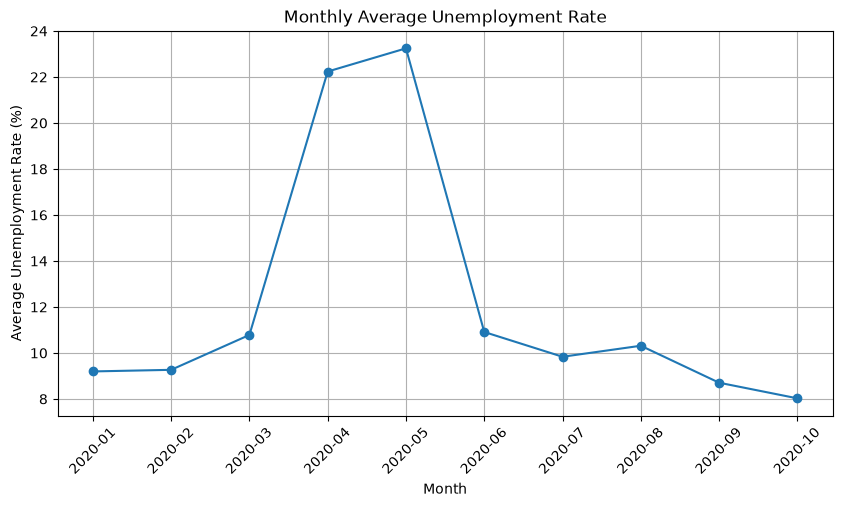

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_unemployment.index.astype(str),
    monthly_unemployment.values,
    marker='o'
)

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

The unemployment rate was around 9% in January and February.

It increased in March and reached the highest point in May at about 23.24%.

After May, the unemployment rate decreased. By October, it came down to
about 8.03%.

The chart shows a clear increase in unemployment during April and May,
followed by a decrease in the later months.

In [20]:
df.groupby(df['Date'].dt.to_period('M'))['Estimated Employed'].mean()

Date
2020-01    1.563720e+07
2020-02    1.548827e+07
2020-03    1.453866e+07
2020-04    1.057020e+07
2020-05    1.150739e+07
2020-06    1.385739e+07
2020-07    1.441802e+07
2020-08    1.442904e+07
2020-09    1.458784e+07
2020-10    1.457998e+07
Freq: M, Name: Estimated Employed, dtype: float64

### Observation

The average number of employed people was highest in January at about
15.64 million.

It decreased during March and reached the lowest point in April at about
10.57 million.

After April, the number of employed people started to increase and stayed
around 14 to 15 million in the later months.

## 14. Monthly Employment Trend

Here we plot the average number of employed people for each month.

The chart helps us understand how employment changed during the year.

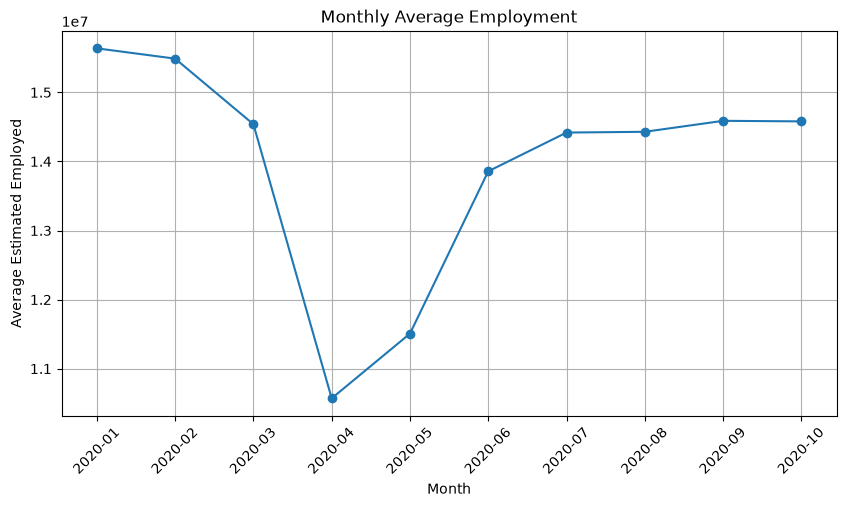

In [22]:
monthly_employed = (
    df.groupby(df['Date'].dt.to_period('M'))['Estimated Employed']
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_employed.index.astype(str),
    monthly_employed.values,
    marker='o'
)

plt.title("Monthly Average Employment")
plt.xlabel("Month")
plt.ylabel("Average Estimated Employed")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

The number of employed people was highest in January.

It decreased from January to April and reached the lowest point in April at
about 10.57 million.

After April, employment started to increase and reached around 14.58 million
by October.